In [1]:
import numpy as np
import pandas as pd
from scipy import sparse

import torch
from torch_geometric.data import Data


# ======================
# Load data
# ======================

X = np.load(
    "GCN_features.npy"
)

A = sparse.load_npz(
    "GCN_adjacency.npz"
)

metadata = pd.read_csv(
    "GCN_metadata.csv",
    index_col=0
)


print(X.shape)
print(A.shape)
print(metadata.shape)

(49393, 3000)
(49393, 49393)
(49393, 5)


In [2]:
labels = metadata["label"].values

y = torch.tensor(
    labels,
    dtype=torch.long
)

In [3]:
from sklearn.model_selection import train_test_split


# 有標籤的位置
label_idx = np.where(labels != -1)[0]


# train / validation
train_idx, val_idx = train_test_split(
    label_idx,
    test_size=0.2,
    stratify=labels[label_idx],
    random_state=42
)


train_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)

val_mask = torch.zeros(
    len(labels),
    dtype=torch.bool
)


train_mask[train_idx] = True
val_mask[val_idx] = True


print("Train:", train_mask.sum())
print("Validation:", val_mask.sum())
print("Unknown:", (labels==-1).sum())

Train: tensor(7476)
Validation: tensor(1870)
Unknown: 40047


In [4]:
edge_index = torch.tensor(
    np.vstack(A.nonzero()),
    dtype=torch.long
)


print(edge_index.shape)

torch.Size([2, 1078614])


In [5]:
data = Data(
    x=torch.tensor(
        X,
        dtype=torch.float
    ),

    edge_index=edge_index,

    y=y,

    train_mask=train_mask,

    val_mask=val_mask
)

print(data)

Data(x=[49393, 3000], edge_index=[2, 1078614], y=[49393], train_mask=[49393], val_mask=[49393])


In [6]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = GCNConv(
            3000,
            64
        )

        self.conv2 = GCNConv(
            64,
            2
        )


    def forward(self, x, edge_index):

        x = self.conv1(
            x,
            edge_index
        )

        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.5,
            training=self.training
        )


        x = self.conv2(
            x,
            edge_index
        )

        return x

In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


data = data.to(device)

model = GCN().to(device)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4
)


loss_fn = torch.nn.CrossEntropyLoss()

print("以下為訓練過程:")

# Early stopping parameters
best_val_acc = 0          # 紀錄最佳 validation accuracy
patience = 20             # 容忍20次沒有改善
counter = 0               # 計算多久沒改善

best_model_path = "best_GCN_model.pt"

for epoch in range(100):

    model.train()

    optimizer.zero_grad()


    out = model(
        data.x,
        data.edge_index
    )


    loss = loss_fn(
        out[data.train_mask],
        data.y[data.train_mask]
    )


    loss.backward()

    optimizer.step()



    # validation

    model.eval()

    with torch.no_grad():

        val_out = model(
            data.x,
            data.edge_index
        )

        pred = val_out.argmax(dim=1) # 選擇模型輸出最高的類別

        correct = (
            pred[data.val_mask]
            ==
            data.y[data.val_mask]
        ).sum()

        acc = correct / data.val_mask.sum()

    if epoch % 10 == 0:

        print(
            epoch,
            "Loss:",
            loss.item(),
            "Val Acc:",
            acc.item()
        )


以下為訓練過程:
0 Loss: 0.9607120752334595 Val Acc: 0.7604278326034546
10 Loss: 1.1036875247955322 Val Acc: 0.9529411792755127
20 Loss: 0.6688238978385925 Val Acc: 0.9614973068237305
30 Loss: 0.35340195894241333 Val Acc: 0.936898410320282
40 Loss: 0.2651931345462799 Val Acc: 0.9743315577507019
50 Loss: 0.187160924077034 Val Acc: 0.9636363387107849
60 Loss: 0.14725546538829803 Val Acc: 0.9732620120048523
70 Loss: 0.11870220303535461 Val Acc: 0.978074848651886
80 Loss: 0.09688639640808105 Val Acc: 0.9796791672706604
90 Loss: 0.08199258148670197 Val Acc: 0.9791443943977356


In [8]:
from sklearn.metrics import confusion_matrix, classification_report


model.eval()

with torch.no_grad():

    out = model(
        data.x,
        data.edge_index
    )

    pred = out.argmax(dim=1) # 選擇模型輸出最高的類別

    # 感染機率 (class 1)
    prob = torch.softmax(
        out,
        dim=1
    )[:,1]

metadata["predict_label"] = pred
metadata["infect_prob"] = prob.cpu().numpy()



y_true = (
    data.y[data.val_mask]
    .cpu()
    .numpy()
)

y_pred = (
    pred[data.val_mask]
    .cpu()
    .numpy()
)

y_prob = (
    prob[data.val_mask]
    .cpu()
    .numpy()
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_true,
        y_pred
    )
)

print("")
print("Classification report:")
print(
    classification_report(
        y_true,
        y_pred
    )
)

Confusion matrix:
[[1492   10]
 [  26  342]]

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1502
           1       0.97      0.93      0.95       368

    accuracy                           0.98      1870
   macro avg       0.98      0.96      0.97      1870
weighted avg       0.98      0.98      0.98      1870



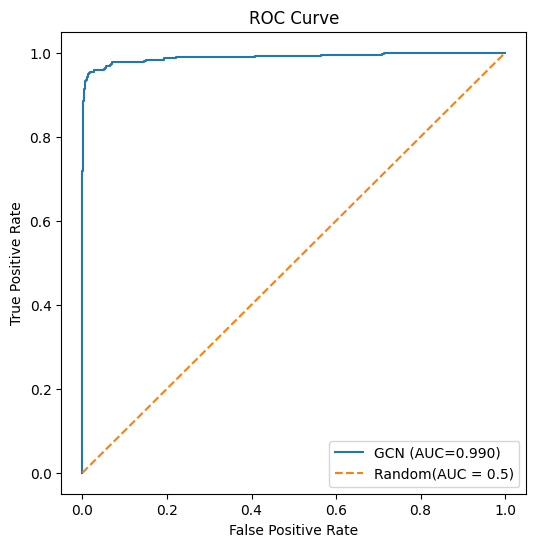

In [9]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


# 計算 ROC curve
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)


# 計算 AUC
auc = roc_auc_score(
    y_true,
    y_prob
)


plt.figure(figsize=(6,6))


plt.plot(
    fpr,
    tpr,
    label=f"GCN (AUC={auc:.3f})"
)


# random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random(AUC = 0.5)"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curve"
)


plt.legend()

plt.show()

In [10]:
print(
    "ROC-AUC:",
    round(auc,4)
)

ROC-AUC: 0.9896


In [11]:
from sklearn.metrics import average_precision_score


pr_auc = average_precision_score(
    y_true,
    y_prob
)


print(
    "PR-AUC:",
    round(pr_auc,4)
)

PR-AUC: 0.9806


In [12]:
healthy = metadata[metadata["label"] == 0]

infected = metadata[metadata["label"] == 1]

unknown_pred_healthy = metadata[
    (metadata["label"] == -1) &
    (metadata["predict_label"] == 0)
]

unknown_pred_infected = metadata[
    (metadata["label"] == -1) &
    (metadata["predict_label"] == 1)
]

In [13]:
unknown = metadata[metadata["label"] == -1]

# 將原本未知的細胞資訊匯出
save_path = r"C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad的細胞標籤\將mock拿掉重跑\GCN_unknown_prediction.csv"

unknown.to_csv(
    save_path,
    encoding="utf-8-sig"
)

print("CSV 已輸出:")
print(save_path)
print("資料大小:", unknown.shape)

CSV 已輸出:
C:\Users\USER\Desktop\資訊所實習\計畫\資料探勘\Ravindra2021.raw_count.stdprep.h5ad的細胞標籤\將mock拿掉重跑\GCN_unknown_prediction.csv
資料大小: (40047, 7)


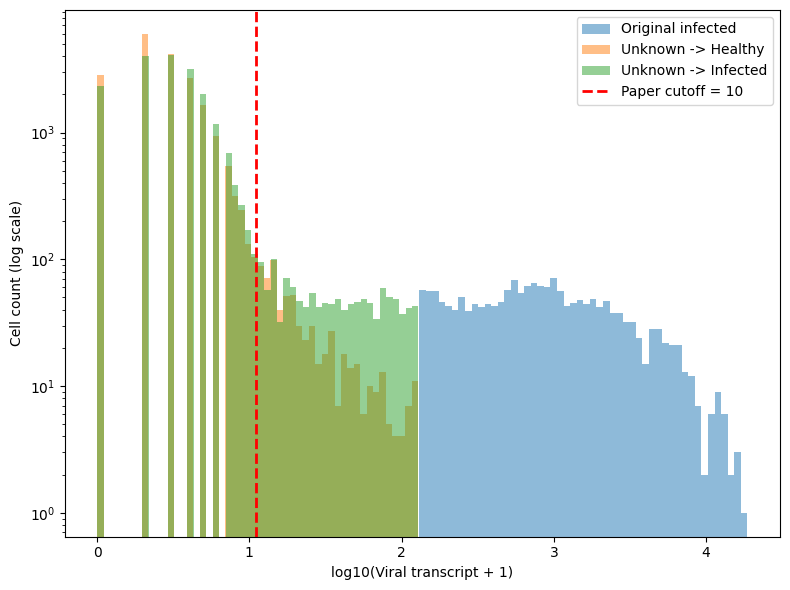

In [14]:
plt.figure(figsize=(8,6))

plt.hist(
    np.log10(infected["Viral_transcript"] + 1),
    bins=50,
    alpha=0.5,
    label="Original infected"
)

plt.hist(
    np.log10(unknown_pred_healthy["Viral_transcript"] + 1),
    bins=50,
    alpha=0.5,
    label="Unknown -> Healthy"
)

plt.hist(
    np.log10(unknown_pred_infected["Viral_transcript"] + 1),
    bins=50,
    alpha=0.5,
    label="Unknown -> Infected"
)

plt.axvline(
    np.log10(11),   # 對應 Viral transcript = 10
    color="red",
    linestyle="--",
    linewidth=2,
    label="Paper cutoff = 10"
)

plt.yscale("log")   # y 軸改成 log scale

plt.xlabel("log10(Viral transcript + 1)")
plt.ylabel("Cell count (log scale)")

plt.legend()
plt.tight_layout()
plt.show()

In [15]:
low_viral = unknown_pred_infected[
    unknown_pred_infected["Viral_transcript"] < 10
]

print(f"Unknown → Infected: {len(unknown_pred_infected)} cells")
print(f"Viral transcript < 10: {len(low_viral)} cells")
print(f"Percentage: {len(low_viral)/len(unknown_pred_infected)*100:.2f}%")

Unknown → Infected: 19823 cells
Viral transcript < 10: 18001 cells
Percentage: 90.81%


In [16]:
viral = unknown_pred_infected["Viral_transcript"]

print("0:", (viral == 0).sum())
print("1~9:", ((viral > 0) & (viral < 10)).sum())
print("10~99:", ((viral >= 10) & (viral < 100)).sum())
print(">=100:", (viral >= 100).sum())

0: 2289
1~9: 15712
10~99: 1378
>=100: 444


In [17]:
print(unknown_pred_infected["infect_prob"].describe())

count    19823.000000
mean         0.899283
std          0.134337
min          0.500131
25%          0.847043
50%          0.967675
75%          0.995676
max          1.000000
Name: infect_prob, dtype: float64


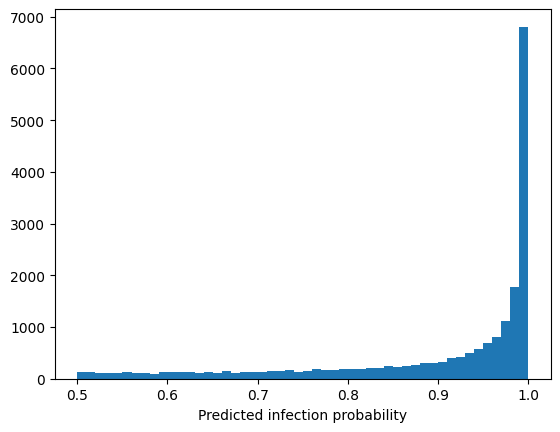

In [18]:
plt.hist(unknown_pred_infected["infect_prob"], bins=50)
plt.xlabel("Predicted infection probability")
plt.show()

In [19]:
zero_cells = unknown_pred_infected[
    unknown_pred_infected["Viral_transcript"] == 0
]

print(
    zero_cells["infect_prob"].describe()
)

count    2289.000000
mean        0.882038
std         0.141141
min         0.500209
25%         0.805202
50%         0.947713
75%         0.992541
max         1.000000
Name: infect_prob, dtype: float64


In [20]:
bins = [
    ("0", metadata["Viral_transcript"] == 0),
    ("1-9", (metadata["Viral_transcript"] > 0) &
            (metadata["Viral_transcript"] < 10)),
    ("10-99", (metadata["Viral_transcript"] >= 10) &
              (metadata["Viral_transcript"] < 100)),
    (">=100", metadata["Viral_transcript"] >= 100)
]

for name, mask in bins:
    print(name)
    print(metadata.loc[mask, "infect_prob"].describe())
    print()

0
count    1.383900e+04
mean     1.726580e-01
std      3.318311e-01
min      5.719970e-18
25%      1.664324e-05
50%      9.077637e-04
75%      9.279806e-02
max      1.000000e+00
Name: infect_prob, dtype: float64

1-9
count    3.376000e+04
mean     4.632656e-01
std      4.255137e-01
min      1.282392e-13
25%      1.098648e-02
50%      3.807521e-01
75%      9.549349e-01
max      1.000000e+00
Name: infect_prob, dtype: float64

10-99
count    2.188000e+03
mean     6.263605e-01
std      4.238792e-01
min      5.812464e-10
25%      9.106208e-02
50%      9.125154e-01
75%      9.972491e-01
max      1.000000e+00
Name: infect_prob, dtype: float64

>=100
count    2194.000000
mean        0.914058
std         0.234361
min         0.000001
25%         0.989972
50%         0.999926
75%         1.000000
max         1.000000
Name: infect_prob, dtype: float64



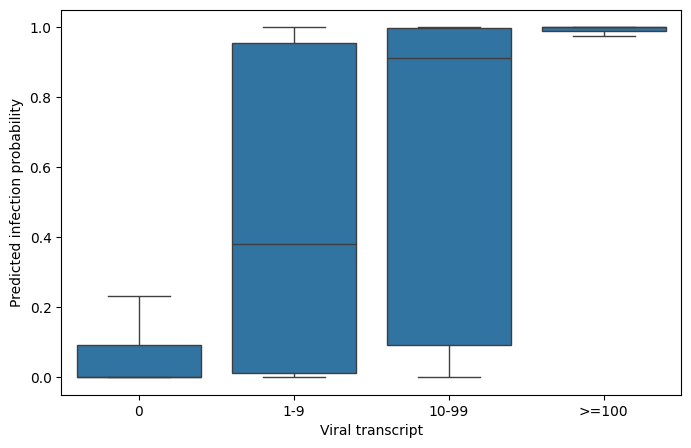

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = metadata.copy()

plot_df["Transcript_group"] = pd.cut(
    plot_df["Viral_transcript"],
    bins=[-1,0,9,99,float("inf")],
    labels=["0","1-9","10-99",">=100"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=plot_df,
    x="Transcript_group",
    y="infect_prob",
    showfliers=False
)

plt.xlabel("Viral transcript")
plt.ylabel("Predicted infection probability")

plt.show()

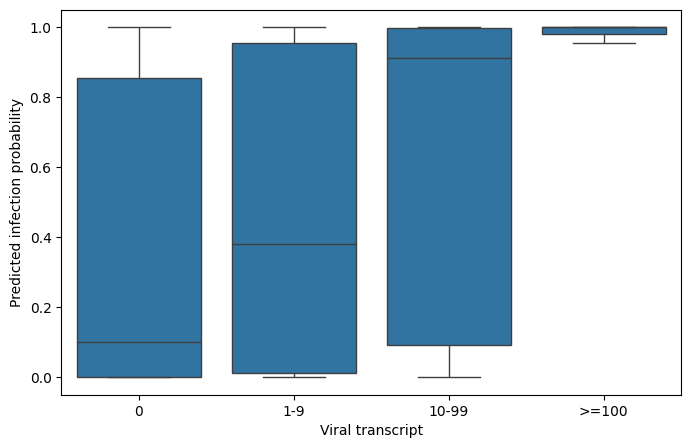

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = metadata[
    metadata["label"] == -1 # 只看unknown的cell
].copy()

plot_df["Transcript_group"] = pd.cut(
    plot_df["Viral_transcript"],
    bins=[-1,0,9,99,float("inf")],
    labels=["0","1-9","10-99",">=100"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=plot_df,
    x="Transcript_group",
    y="infect_prob",
    showfliers=False
)

plt.xlabel("Viral transcript")
plt.ylabel("Predicted infection probability")

plt.show()